### Imports and load data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/jana/Documents/Github/Data_Mining_Project/dataset/processed/image_features.csv")
df = df.drop(columns=["error"])
print(df.shape)
df.head()

(60000, 22)


,path,filename,split,label,ext,orig_width,orig_height,width,height,aspect_ratio,...,mean_b,std_r,std_g,std_b,brightness,contrast,entropy,sharpness,edge_density,colorfulness
0,/Users/jana/Documents/Github/Data_Mining_Proje...,0071.jpg,test,real,.jpg,800,455,256,256,1.758242,...,81.142731,78.846701,80.070388,71.296612,121.370941,77.573049,7.922745,2648.262433,0.198181,55.298258
1,/Users/jana/Documents/Github/Data_Mining_Proje...,4217.jpg,test,real,.jpg,1080,1620,256,256,0.666667,...,185.304077,36.932017,41.233024,53.079293,176.241531,39.498801,6.731529,231.760054,0.028976,42.816157
2,/Users/jana/Documents/Github/Data_Mining_Proje...,3578.jpg,test,real,.jpg,1080,720,256,256,1.500000,...,71.447830,48.873092,41.627177,43.153407,66.234970,41.699535,7.251361,1809.504625,0.206909,41.967958
3,/Users/jana/Documents/Github/Data_Mining_Proje...,2666.jpg,test,real,.jpg,1080,1620,256,256,0.666667,...,28.349030,20.886327,22.823957,15.364015,32.806351,20.987434,5.714562,2008.046290,0.141129,17.450586
4,/Users/jana/Documents/Github/Data_Mining_Proje...,5109.jpg,test,real,.jpg,1449,1069,256,256,1.355472,...,30.448074,20.333942,16.172023,6.890060,52.705078,16.113609,5.632007,101.842324,0.021729,24.015448


### Feature list

In [3]:
feature_cols = [
    "orig_width", "orig_height", "aspect_ratio",
    "mean_r", "mean_g", "mean_b",
    "std_r", "std_g", "std_b",
    "brightness", "contrast", "entropy",
    "sharpness", "edge_density", "colorfulness"
]

In [4]:
summary_by_label = df.groupby("label")[feature_cols].mean().T
summary_by_label

label,fake,real
orig_width,1241.643667,2217.246833
orig_height,1189.325967,2203.189100
aspect_ratio,1.098932,1.057806
mean_r,114.602251,115.119788
mean_g,106.583412,110.045697
mean_b,99.017621,101.518010
std_r,59.702474,55.274942
std_g,55.923261,51.731776
std_b,53.703737,51.481773
brightness,108.119836,110.587980


### Feature difference table

In [5]:
feature_diff = pd.DataFrame({
    "real_mean": df[df["label"] == "real"][feature_cols].mean(),
    "fake_mean": df[df["label"] == "fake"][feature_cols].mean()
})

feature_diff["diff"] = feature_diff["real_mean"] - feature_diff["fake_mean"]
feature_diff["abs_diff"] = feature_diff["diff"].abs()
feature_diff = feature_diff.sort_values("abs_diff", ascending=False)

feature_diff

,real_mean,fake_mean,diff,abs_diff
orig_height,2203.189100,1189.325967,1013.863133,1013.863133
orig_width,2217.246833,1241.643667,975.603167,975.603167
sharpness,1160.120644,1643.532467,-483.411823,483.411823
colorfulness,37.904346,45.808404,-7.904057,7.904057
std_r,55.274942,59.702474,-4.427531,4.427531
std_g,51.731776,55.923261,-4.191485,4.191485
mean_g,110.045697,106.583412,3.462285,3.462285
contrast,51.465203,54.722378,-3.257175,3.257175
mean_b,101.518010,99.017621,2.500389,2.500389
brightness,110.587980,108.119836,2.468145,2.468145


### Plot top feature differences

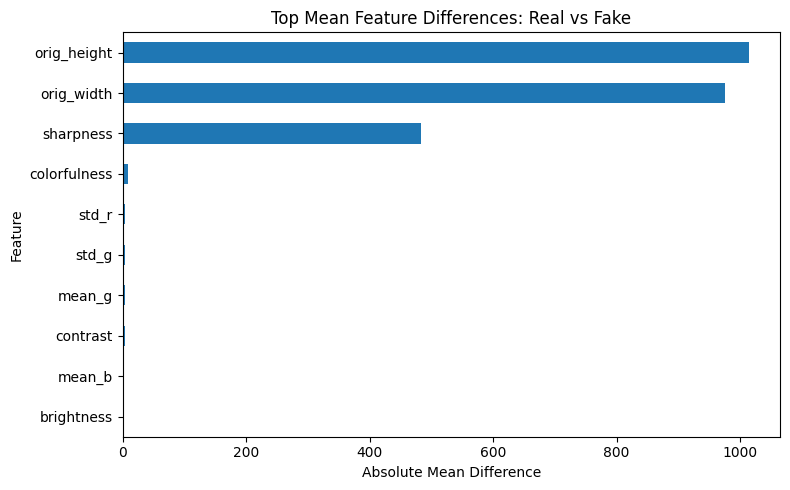

In [6]:
feature_diff["abs_diff"].head(10).sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Top Mean Feature Differences: Real vs Fake")
plt.xlabel("Absolute Mean Difference")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#### Interpretation
AI-generated images in this dataset tend to look more visually intense and structurally crisp than real images, with higher sharpness, stronger color variation, and denser edges.

### Correlation Matrix

In [7]:
corr = df[feature_cols].corr()
corr

,orig_width,orig_height,aspect_ratio,mean_r,mean_g,mean_b,std_r,std_g,std_b,brightness,contrast,entropy,sharpness,edge_density,colorfulness
orig_width,1.000000,0.822106,0.267848,-0.088734,-0.028743,-0.001304,-0.072129,-0.081652,-0.028128,-0.045482,-0.064726,-0.030108,-0.091786,-0.084822,-0.085879
orig_height,0.822106,1.000000,-0.175558,-0.072589,-0.018518,0.003340,-0.051289,-0.052729,0.004029,-0.033718,-0.034170,-0.038284,-0.087089,-0.086975,-0.106474
aspect_ratio,0.267848,-0.175558,1.000000,-0.038465,-0.026663,-0.016006,-0.046014,-0.054315,-0.053770,-0.029984,-0.057427,0.021067,-0.024452,0.004613,0.029429
mean_r,-0.088734,-0.072589,-0.038465,1.000000,0.901191,0.775497,0.122841,0.245608,0.291982,0.946451,0.222732,-0.010680,0.164349,0.075120,0.085572
mean_g,-0.028743,-0.018518,-0.026663,0.901191,1.000000,0.924175,0.088258,0.256720,0.353744,0.991633,0.233732,-0.033001,0.183086,0.068418,-0.031803
mean_b,-0.001304,0.003340,-0.016006,0.775497,0.924175,1.000000,0.070728,0.234255,0.374189,0.915617,0.215245,-0.078745,0.171784,0.018044,-0.087805
std_r,-0.072129,-0.051289,-0.046014,0.122841,0.088258,0.070728,1.000000,0.806573,0.620841,0.099973,0.867191,0.298682,0.231026,0.208550,0.275024
std_g,-0.081652,-0.052729,-0.054315,0.245608,0.256720,0.234255,0.806573,1.000000,0.866686,0.258743,0.980770,0.293426,0.263706,0.220839,0.076773
std_b,-0.028128,0.004029,-0.053770,0.291982,0.353744,0.374189,0.620841,0.866686,1.000000,0.347908,0.848202,0.245770,0.220781,0.184911,0.057705
brightness,-0.045482,-0.033718,-0.029984,0.946451,0.991633,0.915617,0.099973,0.258743,0.347908,1.000000,0.235528,-0.032407,0.181670,0.066759,-0.002248


### Correlation heatmap

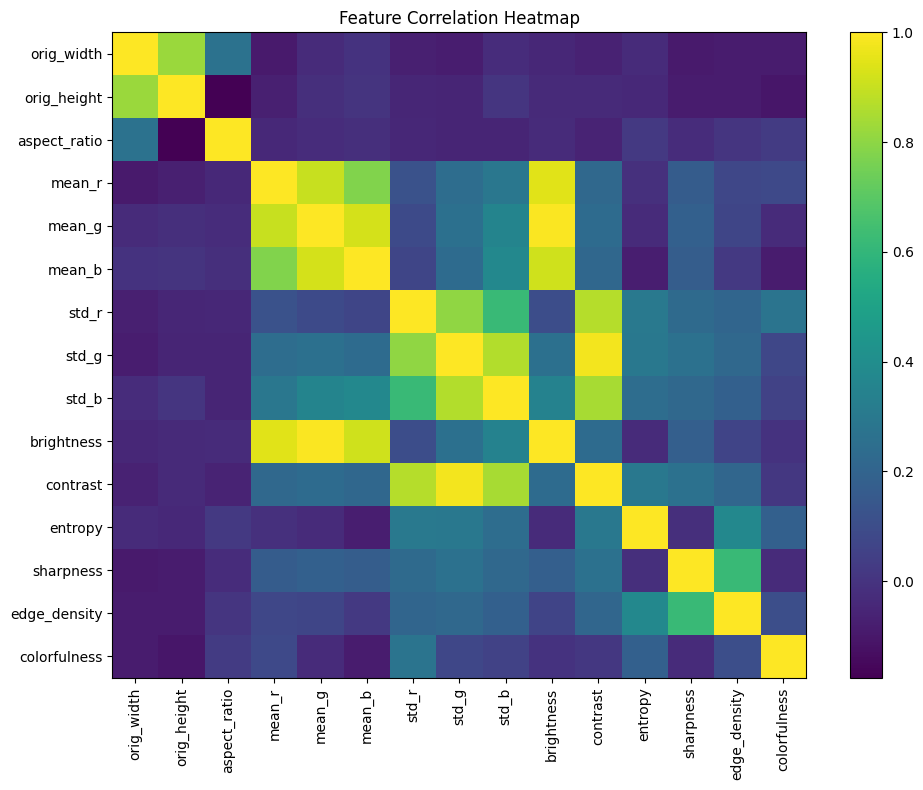

In [8]:
plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

### Standardize features for PCA

In [9]:
from sklearn.preprocessing import StandardScaler

X = df[feature_cols].copy()
y = df["label"].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape

(60000, 15)

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "label": y.values
})

print("Explained variance ratio:", pca.explained_variance_ratio_)
df_pca.head()

Explained variance ratio: [0.31788309 0.19576247]


,PC1,PC2,label
0,2.503521,2.158227,real
1,0.791800,-3.183281,real
2,-1.644940,0.861640,real
3,-4.816116,-0.453720,real
4,-5.198120,-1.760897,real


### PCA scatter plot

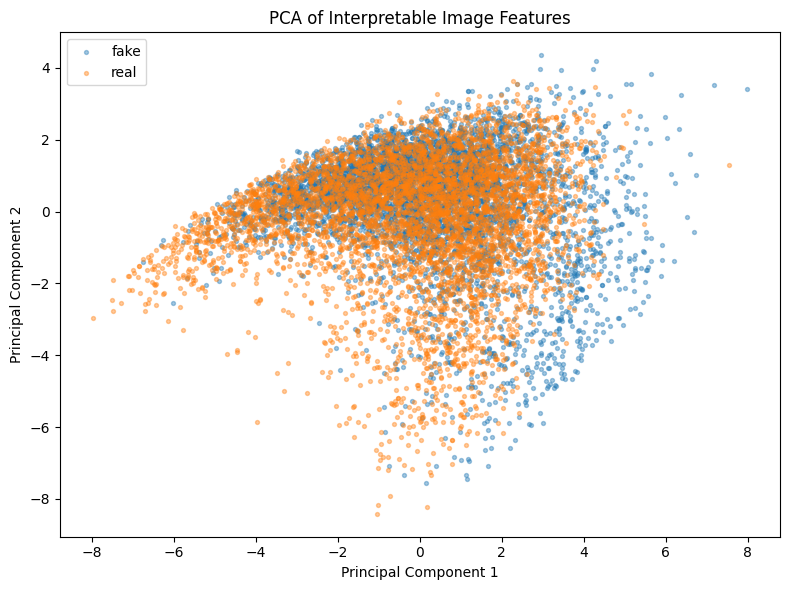

In [11]:
import warnings
warnings.simplefilter("ignore", DeprecationWarning)

plot_df = (
    df_pca.groupby("label", group_keys=False)
    .apply(lambda x: x.sample(n=min(5000, len(x)), random_state=42))
    .reset_index(drop=True)
)

plt.figure(figsize=(8, 6))

for label, subset in plot_df.groupby("label"):
    plt.scatter(subset["PC1"], subset["PC2"], s=8, alpha=0.4, label=label)

plt.title("PCA of Interpretable Image Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
df_pca.groupby("label")[["PC1", "PC2"]].mean()

,PC1,PC2
label,,
fake,0.196845,0.270818
real,-0.196845,-0.270818


Simple interpretable image features do not perfectly separate real and fake images, but they do create a noticeable shift in feature space, indicating that AI-generated images have mesurable visual signatures.

In [13]:
df_pca.to_csv("/Users/jana/Documents/Github/Data_Mining_Project/dataset/processed/image_features_pca.csv", index=False)
print("Saved PCA file.")

Saved PCA file.
